<a name="extraccion"></a>
#📌 Extracción

##Ver tarjeta "Extracción de datos" de Trello

In [ ]:
import pandas as pd
import requests
import json

#URL del archivo de entrada JSON
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

#Descarga del archivo de entrada JSON
response = requests.get(url)

#Verificar si la descarga fue correcta
if response.status_code == 200:
    #Cargar el archivo de entrada JSON en un diccionario
    data = json.loads(response.text)
    #Cargar el diccionario en un DataFrame normalizado
    df = pd.json_normalize(data)
    print("JSON file loaded sucessfully")

else:
    print(f"Error al descargar el archivo de entrada JSON. Estado: {response.status_code}")

JSON file loaded sucessfully


<a name="conoce-el-conjunto-de-datos"></a>
##Ver tarjeta "Conoce el conjunto de datos" de Trello

In [ ]:
#Revisar los primeros registros del DF
print("\n\33[1mRevisar los primeros registros del DF\33[0m\n")
print(df.head())
#Revisar la estructura del DF
print("\n\33[1mRevisar la estructura del DF\33[0m\n")
print(df.info())
#Revisar la estructura del DF
print("\n\33[1mRevisar las estadísticas básicas del DF\33[0m\n")
print(df.describe())


Revisar los primeros registros del DF

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                 

<a name="transformacion"></a>
#🔧 Transformación

##Ver tarjeta "Comprobación de incoherencias en los datos" de Trello

##Ver tarjeta "Manejo de inconsistencias" de Trello

<a name="validacion-de-la-integridad-de-la-variable-customerid"></a>
###Validación de la integridad de la variable customerID

In [ ]:
#Código para reportar los valores de la columna 'customerID' qué deben estar en el formato 'dddd-LLLLL' (4 digits, hyphen, 5 uppercase A-Z)
#Si es válido el valor para todo el DF, convierte la columna a un tipo 'string'
#SI encuentra al menos un valor no válido, lista los problemas
#Suposición: Todos los valores son IDs diferentes

import re
import pandas as pd

"""
Validates that df[col] matches pattern 'dddd-LLLLL' (4 digits, hyphen, 5 uppercase A-Z).
If valid, converts df[col] to pandas StringDtype ('string') and returns df.

allow_na=True means NaN/None are allowed and ignored in validation.
"""

print("\n\33[1mVerifico la integridad de la columna customerID (formato 'dddd-LLLLL')\33[0m")

col = "customerID"
allow_na=False
pattern = re.compile(r"^[0-9]{4}-[A-Z]{5}$")

s = df[col]

# Build mask of which values should be validated
if allow_na:
  to_check = s.dropna()
else:
  to_check = s

# Convert to string for matching (important if there are non-strings in an object column)
to_check_str = to_check.astype(str)

# Identify invalid values
invalid_mask = ~to_check_str.str.match(pattern)

if invalid_mask.any():
  invalid_values = to_check_str[invalid_mask]

  # Return useful debugging info: indices + offending values
  problems = pd.DataFrame({
  "index": invalid_values.index,
  "value": invalid_values.values
  }).reset_index(drop=True)

  raise ValueError(
  f"Column '{col}' has {len(problems)} invalid value(s). "
  f"Expected format 'dddd-LLLLL'. Examples:\n{problems.head(20).to_string(index=False)}"
  )

# All good -> convert to pandas string dtype
print("La columna 'customerID' contiene sus valores en formato correcto")
df[col] = s.astype("string")


Verifico la integridad de la columna customerID (formato 'dddd-LLLLL')
La columna 'customerID' contiene sus valores en formato correcto


<a name="verificacion-de-la-unicidad-de-la-variable-customerid"></a>
###Verificación de la unicidad de la variable customerID

In [ ]:
#Verifico la unicidad de la columna customerID
print("\n\33[1mVerifico la unicidad de la columna customerID\33[0m")

if df['customerID'].is_unique:
    print("La columna 'customerID' es única.")
    nCustomerID = df['customerID'].nunique()
else:
    print("La columna 'customerID' tiene duplicados.")

print(nCustomerID)


Verifico la unicidad de la columna customerID
La columna 'customerID' es única.
7267


<a name="summarize-unique-values"></a>
###Análisis de valores únicos en una variable

In [ ]:
#Código para conocer a través de un análisis los diferentes valores existentes en un Dataframe y una variable o columna
#determinada.
#Toma de entrada un Dataframe y una columna a revisar.
#Regresa 3 estadísticos de ocurrencias de valores de esa columna.

import pandas as pd

def summarize_unique_values(dataframe_name: pd.DataFrame, column_name: str) -> None:
    """
    Prints:
      1) number of unique values (including NaN)
      2) the unique values (including NaN)
      3) each unique value with its count of occurrences (including NaN)
    """
    if column_name not in dataframe_name.columns:
        raise KeyError(f"Column '{column_name}' not found in the DataFrame.")

    s = dataframe_name[column_name]

    # 1) Number of unique values (count NaN as its own category)
    n_unique = s.nunique(dropna=False)
    print(f"\n\33[1mEl conteo de valores únicos de la columna '{column_name}' (incluyendo NaN):\33[0m")
    print(n_unique)

    # 2) Unique values (includes NaN if present)
    uniques = s.unique()
    print(f"\n\33[1mLos valores únicos de la columna '{column_name}' (incluyendo NaN):\33[0m")
    print(uniques)

    # 3) Value counts for each unique value (includes NaN if present)
    counts = s.value_counts(dropna=False)
    lines = "\n".join([f"{repr(val)}: {cnt}" for val, cnt in counts.items()])
    print(f"\n\33[1mFrecuencia de cada valor de la columna '{column_name}' (including NaN):\33[0m")
    print(lines)

    total = counts.sum()
    print(f"\n\33[1mTotal:\33[0m")
    print(total)

# Example usage:
# summarize_unique_values(df, "Metodo de pago")


##Ver tarjeta "Estandarización y transformación de datos (opcional)" de Trello

<a name="recode-to-binary"></a>
###Análisis de normalización (0/1) en una variable

In [ ]:
#Código para convertir cualquier entrada de dos valores en 1 y 0 respectivamente
#y un tercer valor default (en caso de ser valores varios, ambiguos, o NaN)
#Toma de entrada un Dataframe, una columna a revisar y los valores.
#Regresa el Dataframe modificado por los valores enviados deseados

import numpy as np
import pandas as pd

def recode_to_binary(
    dataframe_name: pd.DataFrame,
    column_name: str,
    value_1,
    value_2,
    value_default
) -> pd.DataFrame:
    """
    Rules:
      - values == value_1  -> 1
      - values == value_2  -> 0
      - otherwise          -> int(value_default)

    Modifies the input DataFrame in-place and returns it.
    """

    if column_name not in dataframe_name.columns:
        raise KeyError(f"Column '{column_name}' not found in DataFrame.")

    if value_1 == value_2:
        raise ValueError("value_1 and value_2 must be different to avoid ambiguous mapping.")

    # Ensure default is a valid integer (supports int/bool/'0'/'1'/etc.)
    try:
        default_int = int(value_default)
    except Exception as e:
        raise ValueError(f"value_default must be convertible to int. Got: {value_default!r}") from e

    s = dataframe_name[column_name]

    mask_1 = s.eq(value_1)  # True where value == value_1
    mask_2 = s.eq(value_2)  # True where value == value_2

    # Build output: default everywhere, then override for the two target values
    out = np.full(len(s), default_int, dtype=np.int64)
    out[mask_1.to_numpy()] = 1
    out[mask_2.to_numpy()] = 0

    dataframe_name[column_name] = out
    return dataframe_name


# ---- Example usage ----
# recode_to_binary(df, "Gender", "Male", "Female", 0)     # Male->1, Female->0, else->0
# recode_to_binary(df, "Flag", True, False, 0)           # True->1, False->0, else->0
# recode_to_binary(df, "Answer", "Yes", "No", 0)         # Yes->1, No->0, else->0


In [ ]:
#Código para convertir a One Hot Encoding una columna "column_name" y regresa la columna con el
#prefijo "column_name" y ya convertida a multicolumna OHE

import pandas as pd

def convert_column_to_OHE(
    dataframe_name: pd.DataFrame,
    column_name: str,
    prefix_name: str = ""
) -> pd.DataFrame:
    """
    Rules:
      - column_name -> prefix_column_name (OHE)
    Modifies the input DataFrame in-place and returns it.
    """
    if column_name not in dataframe_name.columns:
        raise KeyError(f"Column '{column_name}' not found in DataFrame.")

    # Create dummy variables for the specified column
    dummies = pd.get_dummies(dataframe_name[column_name], prefix=prefix_name, dummy_na=False)

    # Convert boolean dummies to int (0 or 1)
    dummies = dummies.astype(int)

    # Drop the original column and concatenate the new dummy columns
    dataframe_name = pd.concat([dataframe_name.drop(columns=[column_name]), dummies], axis=1)

    return dataframe_name


# ---- Example usage ----
# convert_column_to_OHE(df, "account.Contract", "account.Contract")     # account.Contract->OHE


<a name="convert-column-to-float-strict"></a>
###Convierte los valores de una columna a tipo float, en caso de poderse, de otra forma, reporta los posibles problemas para su corrección.

In [ ]:
#Código para saber si los valores de una columna se pueden convertir a tipo float
#INPUT: DataFrame, column
#OUTPUT: Si todo bien, DataFrame con column convertida a float, SINO lista de valores a corregir

import pandas as pd

def convert_column_to_float_strict(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Strict conversion:
      - Tries to convert df[col] to float.
      - If ANY value (non-NaN) cannot be converted, prints index + value for all failures
        and does NOT modify the DataFrame.
      - If all convertible (ignoring NaN), converts the entire column to float and returns df.
    """
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in DataFrame.")

    s = df[col]

    # Try conversion without changing df
    converted = pd.to_numeric(s, errors="coerce")

    # Failures = became NaN after conversion, but original was not NaN
    failed_mask = converted.isna() & s.notna()

    if failed_mask.any():
        failed = s[failed_mask]
        for idx, val in failed.items():
            print(f"Cannot convert to float -> index={idx}, value={val!r}")

        print(f"\nAborted: column '{col}' was NOT converted because {failed_mask.sum()} value(s) failed.")
        return df  # leave df unchanged

    # All good: assign conversion
    df[col] = converted.astype(float)
    return df


# Example usage:
# df = convert_column_to_float_strict(df, "Precio")



In [ ]:
summarize_unique_values(df, "Churn")


El conteo de valores únicos de la columna 'Churn' (incluyendo NaN):
3

Los valores únicos de la columna 'Churn' (incluyendo NaN):
['No' 'Yes' '']

Frecuencia de cada valor de la columna 'Churn' (including NaN):
'No': 5174
'Yes': 1869
'': 224

Total:
7267


In [ ]:
#limpieza de los valores de la columna 'Churn' a solo valores 'Yes'(1) y 'No'(0)
#Los valores fuera de 'Yes' y 'No' los convierte a valor_default
#NOTA: Una vez limpia la columna, ya no se puede volver a llamar la función con
#los parámetros originales
valor_default = 0
recode_to_binary(df, "Churn", "Yes", "No", valor_default);
#Validación de corrección de valores
summarize_unique_values(df, "Churn")


El conteo de valores únicos de la columna 'Churn' (incluyendo NaN):
2

Los valores únicos de la columna 'Churn' (incluyendo NaN):
[0 1]

Frecuencia de cada valor de la columna 'Churn' (including NaN):
0: 5398
1: 1869

Total:
7267


In [ ]:
summarize_unique_values(df, "customer.gender")


El conteo de valores únicos de la columna 'customer.gender' (incluyendo NaN):
2

Los valores únicos de la columna 'customer.gender' (incluyendo NaN):
['Female' 'Male']

Frecuencia de cada valor de la columna 'customer.gender' (including NaN):
'Male': 3675
'Female': 3592

Total:
7267


In [ ]:
#limpieza de los valores de la columna 'customer.gender' a solo valores 'Male'(1) y 'Female'(0)
#NOTA: Una vez limpia la columna, ya no se puede volver a llamar la función con
#los parámetros originales
recode_to_binary(df, "customer.gender", "Male", "Female", 0);
#Validación de corrección de valores
summarize_unique_values(df, "customer.gender")


El conteo de valores únicos de la columna 'customer.gender' (incluyendo NaN):
2

Los valores únicos de la columna 'customer.gender' (incluyendo NaN):
[0 1]

Frecuencia de cada valor de la columna 'customer.gender' (including NaN):
1: 3675
0: 3592

Total:
7267


In [ ]:
summarize_unique_values(df, "customer.SeniorCitizen")


El conteo de valores únicos de la columna 'customer.SeniorCitizen' (incluyendo NaN):
2

Los valores únicos de la columna 'customer.SeniorCitizen' (incluyendo NaN):
[0 1]

Frecuencia de cada valor de la columna 'customer.SeniorCitizen' (including NaN):
0: 6085
1: 1182

Total:
7267


In [ ]:
summarize_unique_values(df, "customer.Partner")


El conteo de valores únicos de la columna 'customer.Partner' (incluyendo NaN):
2

Los valores únicos de la columna 'customer.Partner' (incluyendo NaN):
['Yes' 'No']

Frecuencia de cada valor de la columna 'customer.Partner' (including NaN):
'No': 3749
'Yes': 3518

Total:
7267


In [ ]:
#limpieza de los valores de la columna 'customer.Partner' a solo valores 'Yes'(1) y 'No'(0)
#NOTA: Una vez limpia la columna, ya no se puede volver a llamar la función con
#los parámetros originales
recode_to_binary(df, "customer.Partner", "Yes", "No", 0);
#Validación de corrección de valores
summarize_unique_values(df, "customer.Partner")


El conteo de valores únicos de la columna 'customer.Partner' (incluyendo NaN):
2

Los valores únicos de la columna 'customer.Partner' (incluyendo NaN):
[1 0]

Frecuencia de cada valor de la columna 'customer.Partner' (including NaN):
0: 3749
1: 3518

Total:
7267


In [ ]:
summarize_unique_values(df, "customer.Dependents")


El conteo de valores únicos de la columna 'customer.Dependents' (incluyendo NaN):
2

Los valores únicos de la columna 'customer.Dependents' (incluyendo NaN):
['Yes' 'No']

Frecuencia de cada valor de la columna 'customer.Dependents' (including NaN):
'No': 5086
'Yes': 2181

Total:
7267


In [ ]:
#limpieza de los valores de la columna 'customer.Dependents' a solo valores 'Yes'(1) y 'No'(0)
#NOTA: Una vez limpia la columna, ya no se puede volver a llamar la función con
#los parámetros originales
recode_to_binary(df, "customer.Dependents", "Yes", "No", 0);
#Validación de corrección de valores
summarize_unique_values(df, "customer.Dependents")


El conteo de valores únicos de la columna 'customer.Dependents' (incluyendo NaN):
2

Los valores únicos de la columna 'customer.Dependents' (incluyendo NaN):
[1 0]

Frecuencia de cada valor de la columna 'customer.Dependents' (including NaN):
0: 5086
1: 2181

Total:
7267


In [ ]:
summarize_unique_values(df, "phone.PhoneService")


El conteo de valores únicos de la columna 'phone.PhoneService' (incluyendo NaN):
2

Los valores únicos de la columna 'phone.PhoneService' (incluyendo NaN):
['Yes' 'No']

Frecuencia de cada valor de la columna 'phone.PhoneService' (including NaN):
'Yes': 6560
'No': 707

Total:
7267


In [ ]:
#limpieza de los valores de la columna 'phone.PhoneService' a solo valores 'Yes'(1) y 'No'(0)
#NOTA: Una vez limpia la columna, ya no se puede volver a llamar la función con
#los parámetros originales
recode_to_binary(df, "phone.PhoneService", "Yes", "No", 0);
#Validación de corrección de valores
summarize_unique_values(df, "phone.PhoneService")


El conteo de valores únicos de la columna 'phone.PhoneService' (incluyendo NaN):
2

Los valores únicos de la columna 'phone.PhoneService' (incluyendo NaN):
[1 0]

Frecuencia de cada valor de la columna 'phone.PhoneService' (including NaN):
1: 6560
0: 707

Total:
7267


In [ ]:
summarize_unique_values(df, "account.PaperlessBilling")


El conteo de valores únicos de la columna 'account.PaperlessBilling' (incluyendo NaN):
2

Los valores únicos de la columna 'account.PaperlessBilling' (incluyendo NaN):
['Yes' 'No']

Frecuencia de cada valor de la columna 'account.PaperlessBilling' (including NaN):
'Yes': 4311
'No': 2956

Total:
7267


In [ ]:
#limpieza de los valores de la columna 'account.PaperlessBilling' a solo valores 'Yes'(1) y 'No'(0)
#NOTA: Una vez limpia la columna, ya no se puede volver a llamar la función con
#los parámetros originales
recode_to_binary(df, "account.PaperlessBilling", "Yes", "No", 0);
#Validación de corrección de valores
summarize_unique_values(df, "account.PaperlessBilling")


El conteo de valores únicos de la columna 'account.PaperlessBilling' (incluyendo NaN):
2

Los valores únicos de la columna 'account.PaperlessBilling' (incluyendo NaN):
[1 0]

Frecuencia de cada valor de la columna 'account.PaperlessBilling' (including NaN):
1: 4311
0: 2956

Total:
7267


In [ ]:
summarize_unique_values(df, "account.PaymentMethod")


El conteo de valores únicos de la columna 'account.PaymentMethod' (incluyendo NaN):
4

Los valores únicos de la columna 'account.PaymentMethod' (incluyendo NaN):
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Frecuencia de cada valor de la columna 'account.PaymentMethod' (including NaN):
'Electronic check': 2445
'Mailed check': 1665
'Bank transfer (automatic)': 1589
'Credit card (automatic)': 1568

Total:
7267


In [ ]:
#Convierte directamente la columna 'account.PaymentMethod' a string al saber que solo son cadenas
df["account.PaymentMethod"] = df["account.PaymentMethod"].astype('string')

In [ ]:
#Convierte directamente la columna 'account.Charges.Monthly' a float al saber que solo son números float
df["account.Charges.Monthly"] = df["account.Charges.Monthly"].astype(float)

In [ ]:
#Revisa que se pueda convertir la columna 'account.Charges.Total' a un tipo float
df = convert_column_to_float_strict(df, "account.Charges.Total");

Cannot convert to float -> index=975, value=' '
Cannot convert to float -> index=1775, value=' '
Cannot convert to float -> index=1955, value=' '
Cannot convert to float -> index=2075, value=' '
Cannot convert to float -> index=2232, value=' '
Cannot convert to float -> index=2308, value=' '
Cannot convert to float -> index=2930, value=' '
Cannot convert to float -> index=3134, value=' '
Cannot convert to float -> index=3203, value=' '
Cannot convert to float -> index=4169, value=' '
Cannot convert to float -> index=5599, value=' '

Aborted: column 'account.Charges.Total' was NOT converted because 11 value(s) failed.


In [ ]:
#Corrige de la columna 'account.Charges.Total' los valores con espacios y los reemplaza por NaN
#Despues reemplaza esos valores NaN por -1
#Al final reemplaza los valores -1 por la media del DataFrame
import pandas as pd
import numpy as np

df['account.Charges.Total'] = df['account.Charges.Total'].replace(' ', np.nan)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(-1)
df.loc[df['account.Charges.Total'] == -1, 'account.Charges.Total'] = df['account.Charges.Total'].median()

In [ ]:
summarize_unique_values(df, "phone.MultipleLines")


El conteo de valores únicos de la columna 'phone.MultipleLines' (incluyendo NaN):
3

Los valores únicos de la columna 'phone.MultipleLines' (incluyendo NaN):
['No' 'Yes' 'No phone service']

Frecuencia de cada valor de la columna 'phone.MultipleLines' (including NaN):
'No': 3495
'Yes': 3065
'No phone service': 707

Total:
7267


In [ ]:
#Código para normalizar la columna 'phone.MultipleLines' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "phone.MultipleLines", "phone.MultipleLines")

In [ ]:
summarize_unique_values(df, "internet.InternetService")


El conteo de valores únicos de la columna 'internet.InternetService' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.InternetService' (incluyendo NaN):
['DSL' 'Fiber optic' 'No']

Frecuencia de cada valor de la columna 'internet.InternetService' (including NaN):
'Fiber optic': 3198
'DSL': 2488
'No': 1581

Total:
7267


In [ ]:
#Cambio los valores "No" en la columna 'internet.InternetService' por valores 'No internet service'
df['internet.InternetService'] = df['internet.InternetService'].replace('No', 'No internet service')
summarize_unique_values(df, "internet.InternetService")


El conteo de valores únicos de la columna 'internet.InternetService' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.InternetService' (incluyendo NaN):
['DSL' 'Fiber optic' 'No internet service']

Frecuencia de cada valor de la columna 'internet.InternetService' (including NaN):
'Fiber optic': 3198
'DSL': 2488
'No internet service': 1581

Total:
7267


In [ ]:
#Código para normalizar la columna 'internet.InternetService' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "internet.InternetService", "internet.InternetService")

In [ ]:
summarize_unique_values(df, "internet.OnlineSecurity")


El conteo de valores únicos de la columna 'internet.OnlineSecurity' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.OnlineSecurity' (incluyendo NaN):
['No' 'Yes' 'No internet service']

Frecuencia de cada valor de la columna 'internet.OnlineSecurity' (including NaN):
'No': 3608
'Yes': 2078
'No internet service': 1581

Total:
7267


In [ ]:
#Código para normalizar la columna 'internet.OnlineSecurity' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "internet.OnlineSecurity", "internet.OnlineSecurity")

In [ ]:
summarize_unique_values(df, "internet.OnlineBackup")


El conteo de valores únicos de la columna 'internet.OnlineBackup' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.OnlineBackup' (incluyendo NaN):
['Yes' 'No' 'No internet service']

Frecuencia de cada valor de la columna 'internet.OnlineBackup' (including NaN):
'No': 3182
'Yes': 2504
'No internet service': 1581

Total:
7267


In [ ]:
#Código para normalizar la columna 'internet.OnlineBackup' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "internet.OnlineBackup", "internet.OnlineBackup")

In [ ]:
summarize_unique_values(df, "internet.DeviceProtection")


El conteo de valores únicos de la columna 'internet.DeviceProtection' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.DeviceProtection' (incluyendo NaN):
['No' 'Yes' 'No internet service']

Frecuencia de cada valor de la columna 'internet.DeviceProtection' (including NaN):
'No': 3195
'Yes': 2491
'No internet service': 1581

Total:
7267


In [ ]:
#Código para normalizar la columna 'internet.DeviceProtection' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "internet.DeviceProtection", "internet.DeviceProtection")

In [ ]:
summarize_unique_values(df, "internet.TechSupport")


El conteo de valores únicos de la columna 'internet.TechSupport' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.TechSupport' (incluyendo NaN):
['Yes' 'No' 'No internet service']

Frecuencia de cada valor de la columna 'internet.TechSupport' (including NaN):
'No': 3582
'Yes': 2104
'No internet service': 1581

Total:
7267


In [ ]:
#Código para normalizar la columna 'internet.TechSupport' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "internet.TechSupport", "internet.TechSupport")

In [ ]:
summarize_unique_values(df, "internet.StreamingTV")


El conteo de valores únicos de la columna 'internet.StreamingTV' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.StreamingTV' (incluyendo NaN):
['Yes' 'No' 'No internet service']

Frecuencia de cada valor de la columna 'internet.StreamingTV' (including NaN):
'No': 2896
'Yes': 2790
'No internet service': 1581

Total:
7267


In [ ]:
#Código para normalizar la columna 'internet.StreamingTV' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "internet.StreamingTV", "internet.StreamingTV")

In [ ]:
summarize_unique_values(df, "internet.StreamingMovies")


El conteo de valores únicos de la columna 'internet.StreamingMovies' (incluyendo NaN):
3

Los valores únicos de la columna 'internet.StreamingMovies' (incluyendo NaN):
['No' 'Yes' 'No internet service']

Frecuencia de cada valor de la columna 'internet.StreamingMovies' (including NaN):
'No': 2870
'Yes': 2816
'No internet service': 1581

Total:
7267


In [ ]:
#Código para normalizar la columna 'internet.StreamingMovies' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "internet.StreamingMovies", "internet.StreamingMovies")

In [ ]:
summarize_unique_values(df, "account.Contract")


El conteo de valores únicos de la columna 'account.Contract' (incluyendo NaN):
3

Los valores únicos de la columna 'account.Contract' (incluyendo NaN):
['One year' 'Month-to-month' 'Two year']

Frecuencia de cada valor de la columna 'account.Contract' (including NaN):
'Month-to-month': 4005
'Two year': 1743
'One year': 1519

Total:
7267


In [ ]:
#Código para normalizar la columna 'account.Contract' a valores 1 y 0
#de acuerdo a ONE HOT ENCODING de la columna

df = convert_column_to_OHE(df, "account.Contract", "account.Contract")

##Ver tarjeta "Columna de cuentas diarias (Opcional)" de Trello

<a name="create-column-account-charges-daily"></a>
###Se crea la columna Account.Charges.Daily

In [ ]:
df['account.Charges.Daily'] = df['account.Charges.Monthly']/30

##Ver tarjeta "Análisis Descriptivo" de Trello

In [ ]:
df.describe()


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,...,internet.StreamingTV_No,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.Charges.Daily
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,...,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2279.284856,...,0.398514,0.217559,0.383927,0.394936,0.217559,0.387505,0.551122,0.209027,0.239851,2.157337
std,0.437115,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2267.180032,...,0.489626,0.412614,0.486374,0.488871,0.412614,0.487214,0.497414,0.406642,0.427022,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,401.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.180833
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.343333
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,...,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.995833
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.958333


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 40 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   customerID                                     7267 non-null   string 
 1   Churn                                          7267 non-null   int64  
 2   customer.gender                                7267 non-null   int64  
 3   customer.SeniorCitizen                         7267 non-null   int64  
 4   customer.Partner                               7267 non-null   int64  
 5   customer.Dependents                            7267 non-null   int64  
 6   customer.tenure                                7267 non-null   int64  
 7   phone.PhoneService                             7267 non-null   int64  
 8   account.PaperlessBilling                       7267 non-null   int64  
 9   account.PaymentMethod                          7267 

#📊 Carga y análisis

In [ ]:
#Respaldo el Dataframe limpio listo para su análisis en el máquina virtual local
df.to_csv("TelecomX_LATAM.csv", index=False)

In [ ]:
#Copio un Dataframe temporal df2 basado en df para operaciones intermedias y gráficos
df2 = df.copy()

##Revisión de sanidad de datos para prevenir falsos hallazgos (Sanity checks that prevent false insights)

In [ ]:
#Revisión de salud de NO duplicados
df['customerID'].duplicated().sum()


np.int64(0)

In [ ]:
print("Shape:", df.shape)
print("Duplicates in customerID:", df["customerID"].duplicated().sum())
print("Missing cells (NaN):", df.isna().sum().sum())
print("Churn rate:", df["Churn"].mean())

Shape: (7267, 40)
Duplicates in customerID: 0
Missing cells (NaN): 0
Churn rate: 0.257190037154259


##Ver tarjeta "Distribución de evasión" de Trello

<a name="analisis-de-churn-base"></a>
###Análisis del valor de abandono o 'Churn' base

In [ ]:
#Obtención del porcentaje de deserción de clientes
#Este es el punto base de análisis de 'Churn'

df['Churn'].value_counts(normalize=True)


,proportion
Churn,
0,0.74281
1,0.25719


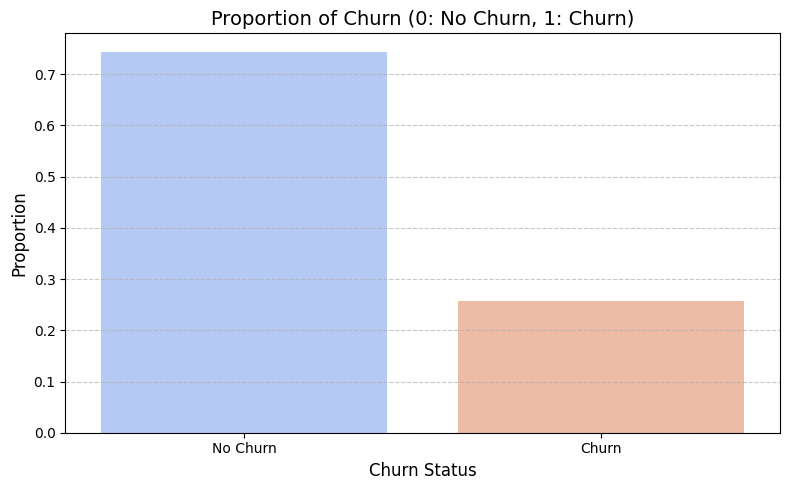

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_proportions = df['Churn'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_proportions.index, y=churn_proportions.values, palette='coolwarm', hue=churn_proportions.index, legend=False)
plt.title('Proportion of Churn (0: No Churn, 1: Churn)', fontsize=14)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Tasa de abandono base y comparaciones de segmento simples (Baseline churn rate and simple segment comparisons)

##Ver tarjeta "Recuento de evasión por variables categóricas" de Trello

<a name="churn-by-category"></a>
###Análisis de variables categóricas contra 'Churn'

In [ ]:
#Revisión de variables categóricas contra 'Churn'
#Parámetros de entrada:
#. min_n = población mínima a analizar
#Parámetros de salida:
#. churn_rate = promedio de Churn en el segmento
#. count = cuántos clientes tiene el segmento
#. lift = churn_rate / churn_base (qué tan arriba/abajo está vs promedio)
#. delta = churn_rate - churn_base (diferencia absoluta)
#

def churn_by_category(df, col, target="Churn", min_n=50):
    overall = df[target].mean()
    t = (df.groupby(col)[target]
           .agg(churn_rate="mean", customers="count")
           .reset_index())
    t["lift"]  = t["churn_rate"] / overall
    t["delta"] = t["churn_rate"] - overall
    t = t[t["customers"] >= min_n].sort_values("churn_rate", ascending=False)
    return t



In [ ]:
#examples
print(churn_by_category(df, 'customer.gender'))
print(churn_by_category(df, 'account.Contract_Month-to-month'))
print(churn_by_category(df, 'account.Contract_One year'))
print(churn_by_category(df, 'account.Contract_Two year'))
print(churn_by_category(df, 'account.PaymentMethod'))

   customer.gender  churn_rate  customers      lift     delta
0                0    0.261414       3592  1.016424  0.004224
1                1    0.253061       3675  0.983946 -0.004129
   account.Contract_Month-to-month  churn_rate  customers      lift     delta
1                                1    0.413233       4005  1.606724  0.156043
0                                0    0.065604       3262  0.255080 -0.191586
   account.Contract_One year  churn_rate  customers      lift     delta
0                          0    0.296277       5748  1.151977  0.039087
1                          1    0.109282       1519  0.424909 -0.147908
   account.Contract_Two year  churn_rate  customers      lift     delta
0                          0    0.329652       5524  1.281746  0.072462
1                          1    0.027539       1743  0.107075 -0.229651
       account.PaymentMethod  churn_rate  customers      lift     delta
2           Electronic check    0.438037       2445  1.703164  0.180847
3   

<a name="churn-rate-by"></a>
###Análisis de variables categóricas contra 'Churn'

In [ ]:
#Análisis del Churn rate por columna categórica
#Este bloque de código calcula el 'Churn' dado la presencia de la variable X (1/0)
#Esto tambien es llamado "Vista de Riesgo"
#P(Churn=1 | X=1) vs P(Churn=1 | X=0)
#Para la variable binaria X (0/1), esa tabla calcula:
#.  P(Churn=1∣X=0 ó 1)
#El significado de la salida es “qué tanto Churn hay dado la variable X”.
#Esto responde a ¿qué tan riesgoso es el X=contrato month-to-month?” (churn dentro del contrato).
#Análisis para indicadores binarios del tipo (1/0)

def churn_rate_by(df, col, target='Churn'):
    return (df.groupby(col)[target]
              .mean()
              .sort_values(ascending=False)
              .to_frame('churn_rate'))


In [ ]:
# examples
print(churn_rate_by(df, 'customer.gender'))
print(churn_rate_by(df, 'account.Contract_Month-to-month'))
print(churn_rate_by(df, 'account.Contract_One year'))
print(churn_rate_by(df, 'account.Contract_Two year'))
print(churn_rate_by(df, 'account.PaymentMethod'))

                 churn_rate
customer.gender            
0                  0.261414
1                  0.253061
                                 churn_rate
account.Contract_Month-to-month            
1                                  0.413233
0                                  0.065604
                           churn_rate
account.Contract_One year            
0                            0.296277
1                            0.109282
                           churn_rate
account.Contract_Two year            
0                            0.329652
1                            0.027539
                           churn_rate
account.PaymentMethod                
Electronic check             0.438037
Mailed check                 0.184985
Bank transfer (automatic)    0.162366
Credit card (automatic)      0.147959


<a name="churn-by-pay"></a>
###Análisis de la variable categórica 'PaymentMethod' contra 'Churn'

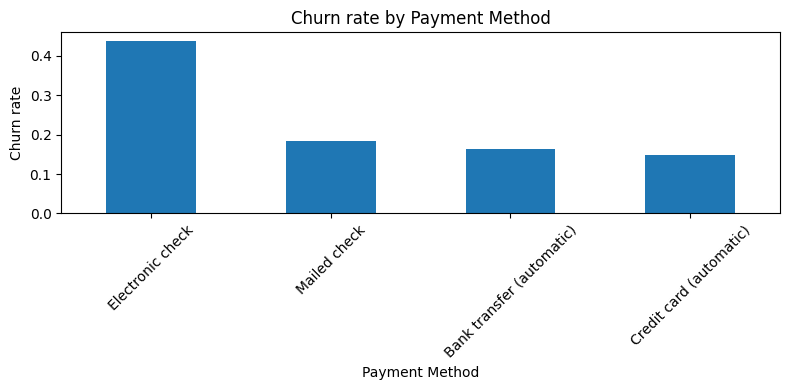

In [ ]:
#Gráfico de barras de 'Churn' VS 'PaymentMethod'

churn_by_pay = (df.groupby("account.PaymentMethod")["Churn"]
                    .mean()
                    .sort_values(ascending=False))

ax = churn_by_pay.plot(kind="bar", rot=45, figsize=(8,4))
ax.set_title("Churn rate by Payment Method")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Churn rate")
plt.tight_layout()
plt.show()


<a name="churn-by-accout-contract"></a>
###Análisis de la variable categórica 'account.Contract' contra 'Churn'

In [ ]:
#Análisis de 'Churn' para columna categórica 'account.Contract_'

contract_cols = [c for c in df.columns if c.startswith("account.Contract_")]

contract_churn = {
    c.replace("account.Contract_", ""): df.loc[df2[c] == 1, "Churn"].mean()
    for c in contract_cols
}
contract_churn


{'Month-to-month': np.float64(0.4132334581772784),
 'One year': np.float64(0.10928242264647794),
 'Two year': np.float64(0.027538726333907058)}

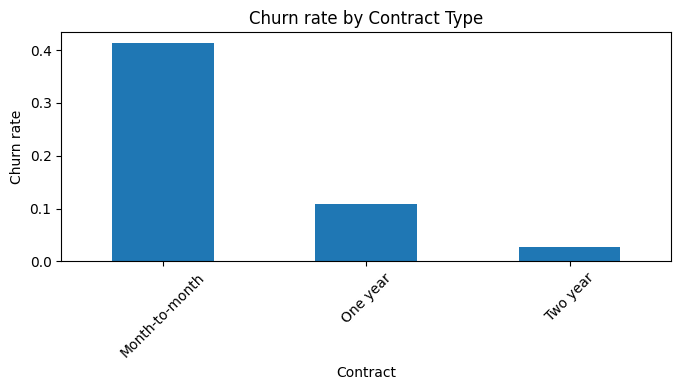

In [ ]:
#Análisis de 'Churn' para columna categórica 'account.Contract_'
#Gráfico
#Create readable 'contract' label if it doesn't exist

if "contract" not in df2.columns:
    contract_cols = [c for c in df2.columns if c.startswith("account.Contract_")]
    df2["contract"] = df2[contract_cols].idxmax(axis=1).str.replace("account.Contract_", "", regex=False)

churn_by_contract = (df2.groupby("contract")["Churn"]
                        .mean()
                        .sort_values(ascending=False))

ax = churn_by_contract.plot(kind="bar", rot=45, figsize=(7,4))
ax.set_title("Churn rate by Contract Type")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn rate")
plt.tight_layout()
plt.show()

<a name="churn-by-accout-internet"></a>
###Análisis de la variable categórica 'internet.InternetService' contra 'Churn'

In [ ]:
#Análisis de 'Churn' para columna categórica 'internet.InternetService_'

internet_cols = [c for c in df.columns if c.startswith("internet.InternetService_")]

internet_churn = {
    c.replace("internet.InternetService_", ""): df.loc[df2[c] == 1, "Churn"].mean()
    for c in internet_cols
}
internet_churn


{'DSL': np.float64(0.18448553054662378),
 'Fiber optic': np.float64(0.40556597873671046),
 'No internet service': np.float64(0.07147375079063883)}

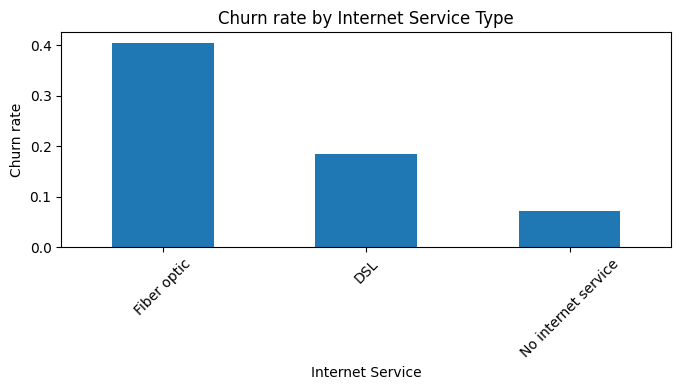

In [ ]:
#Análisis de 'Churn' para columna categórica 'internet.InternetService_'
#Gráfico
#Create readable 'internet' service label if it doesn't exist

if "internet" not in df2.columns:
    internet_cols = [c for c in df2.columns if c.startswith("internet.InternetService_")]
    df2["internet"] = df2[internet_cols].idxmax(axis=1).str.replace("internet.InternetService_", "", regex=False)

churn_by_internet = (df2.groupby("internet")["Churn"]
                        .mean()
                        .sort_values(ascending=False))

ax = churn_by_internet.plot(kind="bar", rot=45, figsize=(7,4))
ax.set_title("Churn rate by Internet Service Type")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn rate")
plt.tight_layout()
plt.show()


##Conductores numéricos: montos facturados, uso, campos similares a la permanencia del servicio (Numerical drivers: billed amounts, usage, tenure-like fields)

##Ver tarjeta "Conteo de evasión por variables numéricas" de Trello

<a name="churn_by_numeric_bins"></a>
###Análisis de variables numéricas contra 'Churn' usando grupos para dividir por percentiles

In [ ]:
#Análisis de variables numéricas contra 'Churn'
#Análisis de evasión por variables numéricas

def churn_by_numeric_bins(df, col, target="Churn", q=8):
    b = pd.qcut(df[col], q=q, duplicates="drop")
    t = (df.groupby(b)[target]
           .agg(churn_rate="mean", customers="count")
           .reset_index()
           .sort_values("churn_rate", ascending=False))
    return t

In [ ]:
#Análisis de variables numéricas contra 'Churn'
#Análisis de evasión por variables numéricas
#example

print(churn_by_numeric_bins(df, "customer.tenure", q=8))
print(churn_by_numeric_bins(df, "account.Charges.Daily", q=8))
print(churn_by_numeric_bins(df, "account.Charges.Monthly", q=8))

  customer.tenure  churn_rate  customers
0   (-0.001, 3.0]    0.543716       1098
1      (3.0, 9.0]    0.393245        829
2     (9.0, 17.0]    0.334168        799
3    (17.0, 29.0]    0.228601        958
4    (29.0, 42.0]    0.210946        877
5    (42.0, 55.0]    0.155655        893
6    (55.0, 67.0]    0.101911        942
7    (67.0, 72.0]    0.045924        871
  account.Charges.Daily  churn_rate  customers
4        (2.343, 2.673]    0.377753        908
6         (2.996, 3.34]    0.371837        909
5        (2.673, 2.996]    0.351441        902
2        (1.181, 1.833]    0.268132        910
7         (3.34, 3.958]    0.264317        908
3        (1.833, 2.343]    0.209200        913
1        (0.677, 1.181]    0.128523        887
0        (0.607, 0.677]    0.088172        930
  account.Charges.Monthly  churn_rate  customers
4            (70.3, 80.2]    0.377753        908
6         (89.875, 100.2]    0.371837        909
5          (80.2, 89.875]    0.351441        902
2          (

/tmp/ipykernel_546/1186267096.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = (df.groupby(b)[target]
/tmp/ipykernel_546/1186267096.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = (df.groupby(b)[target]
/tmp/ipykernel_546/1186267096.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = (df.groupby(b)[target]


<a name="churn_by_numeric"></a>
###Análisis de variables numéricas contra 'Churn'

In [ ]:
#Análisis de variables numéricas contra 'Churn'
#Análisis de evasión por variables numéricas

num_cols = ['customer.tenure', 'account.Charges.Daily', 'account.Charges.Monthly', 'account.Charges.Total']  # add more
df.groupby('Churn')[num_cols].agg(['mean','median','std'])


customer.tenure                   account.Charges.Daily         \
                 mean median        std                  mean median   
Churn                                                                  
0           37.321045   37.0  24.178367              2.045141  2.150   
1           17.979133   10.0  19.531123              2.481378  2.655   

                account.Charges.Monthly                    \
            std                    mean median        std   
Churn                                                       
0      1.036834               61.354224  64.50  31.105006   
1      0.822202               74.441332  79.65  24.666053   

      account.Charges.Total                         
                       mean    median          std  
Churn                                               
0               2538.094878  1663.625  2328.563386  
1               1531.796094   703.550  1890.822994

<a name="binary-driver-summary"></a>
###Sumario de variables binarias contra 'Churn'

In [ ]:
#Interpretación de la salida de ls función binary_driver_summary:
#.  delta_risk grande ⇒ X=1 es un segmento de alto riesgo (ahí actuar)
#.  P_X1_given_churn grande ⇒ muchos churners están ahí (alto alcance)
#.  lift_vs_base grande ⇒ “cuántas veces peor que el promedio” (mensaje ejecutivo).
#Regla práctica de priorización:
#.  Primero: variables con delta_risk alto y n_X1 grande
#.  Después: valida que P_X1_given_churn también sea alto (cobertura)

import pandas as pd

def binary_driver_summary(df, binary_cols, target="Churn"):
    base = df[target].mean()
    out = []
    for x in binary_cols:
        # riesgo
        churn_x1 = df.loc[df[x]==1, target].mean()
        churn_x0 = df.loc[df[x]==0, target].mean()
        # tamaños
        n1 = (df[x]==1).sum()
        n0 = (df[x]==0).sum()

        # composición del churn
        share_in_churn = df.loc[df[target]==1, x].mean()        # P(X=1|Churn=1)
        share_in_nonchurn = df.loc[df[target]==0, x].mean()     # P(X=1|Churn=0)

        out.append({
            "feature": x,
            "n_X1": n1,
            "churn_if_X1": churn_x1,              # P(Churn=1|X=1)
            "churn_if_X0": churn_x0,              # P(Churn=1|X=0)
            "delta_risk": churn_x1 - churn_x0,
            "lift_vs_base": churn_x1 / base,
            "P_X1_given_churn": share_in_churn,   # P(X=1|Churn=1)
            "P_X1_given_nonchurn": share_in_nonchurn,
            "delta_composition": share_in_churn - share_in_nonchurn,
        })

    return (pd.DataFrame(out)
              .sort_values(["delta_risk","P_X1_given_churn"], ascending=False))

binary_cols = [c for c in df.columns if c not in ['customerID','Churn'] and set(df[c].unique()) <= {0,1}]

summary = binary_driver_summary(df, binary_cols)
summary.head(15)

,feature,n_X1,churn_if_X1,churn_if_X0,delta_risk,lift_vs_base,P_X1_given_churn,P_X1_given_nonchurn,delta_composition
30,account.Contract_Month-to-month,4005,0.413233,0.065604,0.347630,1.606724,0.885500,0.435346,0.450154
12,internet.OnlineSecurity_No,3608,0.404933,0.111506,0.293428,1.574452,0.781701,0.397740,0.383962
21,internet.TechSupport_No,3582,0.403685,0.114790,0.288895,1.569598,0.773676,0.395702,0.377974
10,internet.InternetService_Fiber optic,3198,0.405566,0.140575,0.264991,1.576912,0.693954,0.352167,0.341787
15,internet.OnlineBackup_No,3182,0.387492,0.155692,0.231801,1.506637,0.659711,0.361060,0.298651
18,internet.DeviceProtection_No,3195,0.379030,0.161591,0.217438,1.473734,0.647940,0.367544,0.280397
1,customer.SeniorCitizen,1182,0.402707,0.228924,0.173784,1.565797,0.254682,0.130789,0.123892
5,account.PaperlessBilling,4311,0.324751,0.158660,0.166090,1.262687,0.749064,0.539274,0.209790
27,internet.StreamingMovies_No,2870,0.326829,0.211735,0.115094,1.270770,0.501873,0.357910,0.143962
24,internet.StreamingTV_No,2896,0.325276,0.212080,0.113197,1.264731,0.504013,0.361986,0.142027


<a name="service-churn"></a>
###Sumario de variables binarias de servicio contra 'Churn'

In [ ]:
#Este boque de código calcula la proporción de clientes X dado churn/no churn
#Esto tambien es llamado "Vista de Composición"
#P(X=1∣Churn=0 ó 1)
#Para cada variable binaria X (0/1), esa tabla calcula:
#.  non_churn_rate = P(X=1 | Churn=0) :(qué proporción de los que NO se fueron tiene X=1)
#.  churn_rate = P(X=1 | Churn=1) :(qué proporción de los que SÍ se fueron tiene X=1)
#El significado de la salida es “qué tan presente está esa característica (X) dentro del grupo churn”.
#Análisis para indicadores binarios del tipo (1/0)

binary_cols = [c for c in df.columns if c not in ['customerID','Churn'] and set(df[c].unique()) <= {0,1}]

service_churn = (df[binary_cols + ['Churn']]
                   .groupby('Churn')[binary_cols]
                   .mean()
                   .T
                   .rename(columns={0:'non_churn_rate', 1:'churn_rate'}))

service_churn['diff'] = service_churn['churn_rate'] - service_churn['non_churn_rate']
service_churn.sort_values('diff', ascending=False).head(40)


Churn,non_churn_rate,churn_rate,diff
account.Contract_Month-to-month,0.435346,0.885500,0.450154
internet.OnlineSecurity_No,0.397740,0.781701,0.383962
internet.TechSupport_No,0.395702,0.773676,0.377974
internet.InternetService_Fiber optic,0.352167,0.693954,0.341787
internet.OnlineBackup_No,0.361060,0.659711,0.298651
internet.DeviceProtection_No,0.367544,0.647940,0.280397
account.PaperlessBilling,0.539274,0.749064,0.209790
internet.StreamingMovies_No,0.357910,0.501873,0.143962
internet.StreamingTV_No,0.361986,0.504013,0.142027
customer.SeniorCitizen,0.130789,0.254682,0.123892


##Efectos de Interacción (Cómo se ve el churn cuando se combinan factores) ( Interaction effects (what **churn** looks like when features combine))

<a name="contrato-vs-metodo-de-pago"></a>
###Análisis de Churn entre el tipo de contrato VS el método de pago


In [ ]:
#Análisis estadístico de variables combinadas
#Relación entre el tipo de contrato VS el método de pago

pd.pivot_table(
    df,
    values='Churn',
    index='account.Contract_Month-to-month',
    columns='account.PaymentMethod',
    aggfunc='mean'
)




account.PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
account.Contract_Month-to-month,,,,
0,0.058104,0.053412,0.145283,0.035135
1,0.330592,0.319569,0.519060,0.304865


In [ ]:
#Análisis estadístico de variables combinadas
#Relación entre el tipo de contrato VS el método de pago
#Create readable contract label

if "contract" not in df2.columns:
    contract_cols = [c for c in df2.columns if c.startswith("account.Contract_")]
    df2["contract"] = df2[contract_cols].idxmax(axis=1).str.replace("account.Contract_", "", regex=False)

pd.pivot_table(
    df2,
    values="Churn",
    index="contract",
    columns="account.PaymentMethod",
    aggfunc="mean"
)


account.PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
contract,,,,
Month-to-month,0.330592,0.319569,0.519060,0.304865
One year,0.094763,0.099274,0.178273,0.066474
Two year,0.032759,0.021739,0.076023,0.007614


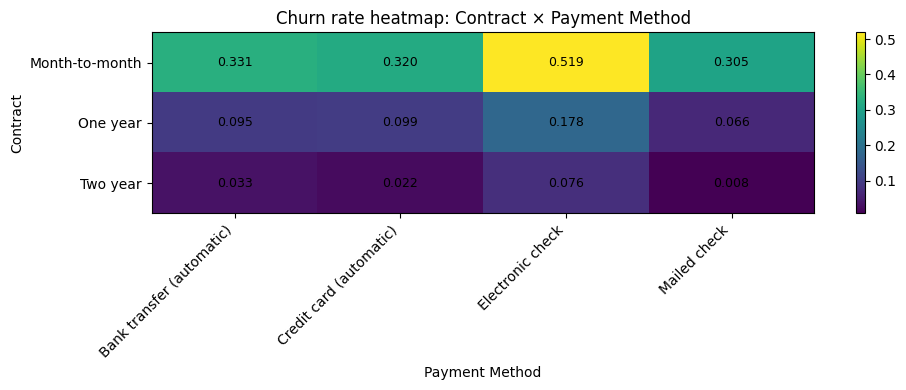

In [ ]:
#Análisis estadístico de variables combinadas
#Relación entre el tipo de contrato VS el método de pago
#Gráfico
#Create readable contract label

if "contract" not in df2.columns:
    contract_cols = [c for c in df2.columns if c.startswith("account.Contract_")]
    df2["contract"] = df2[contract_cols].idxmax(axis=1).str.replace("account.Contract_", "", regex=False)

pivot_cp = pd.pivot_table(
    df2,
    values="Churn", # Added: Specify 'Churn' as the value to aggregate
    index="contract",
    columns="account.PaymentMethod",
    aggfunc="mean"
).sort_index()

fig, ax = plt.subplots(figsize=(10,4))
im = ax.imshow(pivot_cp.values, aspect="auto")

ax.set_title("Churn rate heatmap: Contract × Payment Method")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Contract")

ax.set_xticks(range(pivot_cp.shape[1]))
ax.set_xticklabels(pivot_cp.columns, rotation=45, ha="right")

ax.set_yticks(range(pivot_cp.shape[0]))
ax.set_yticklabels(pivot_cp.index)

# annotate cells
for i in range(pivot_cp.shape[0]):
    for j in range(pivot_cp.shape[1]):
        ax.text(j, i, f"{pivot_cp.values[i, j]:.3f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

<a name="contrato-vs-servicio-de-internet"></a>
###Análisis de Churn entre el tipo de contrato VS el servicio de Internet

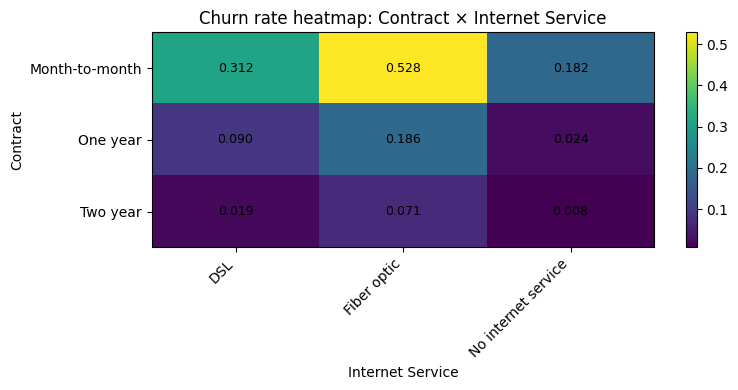

In [ ]:
#Análisis estadístico de variables combinadas
#Relación entre el tipo de contrato VS el Servicio de Internet
#Gráfico

if "contract" not in df2.columns:
    contract_cols = [c for c in df2.columns if c.startswith("account.Contract_")]
    df2["contract"] = df2[contract_cols].idxmax(axis=1).str.replace("account.Contract_", "", regex=False)

# Create readable internet service label if it doesn't exist
if "internet" not in df2.columns:
    internet_cols = [c for c in df2.columns if c.startswith("internet.InternetService_")]
    df2["internet"] = df2[internet_cols].idxmax(axis=1).str.replace("internet.InternetService_", "", regex=False)

pivot_ci = pd.pivot_table(
    df2,
    values="Churn",
    index="contract",
    columns="internet",
    aggfunc="mean"
).sort_index()

fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(pivot_ci.values, aspect="auto")

ax.set_title("Churn rate heatmap: Contract × Internet Service")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Contract")

ax.set_xticks(range(pivot_ci.shape[1]))
ax.set_xticklabels(pivot_ci.columns, rotation=45, ha="right")

ax.set_yticks(range(pivot_ci.shape[0]))
ax.set_yticklabels(pivot_ci.index)

for i in range(pivot_ci.shape[0]):
    for j in range(pivot_ci.shape[1]):
        ax.text(j, i, f"{pivot_ci.values[i, j]:.3f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


<a name="cobro-mensual-vs-servicio-de-internet"></a>
###Análisis entre los cobros mensuales 'account.Charges.Monthly' y el tipo de contrato

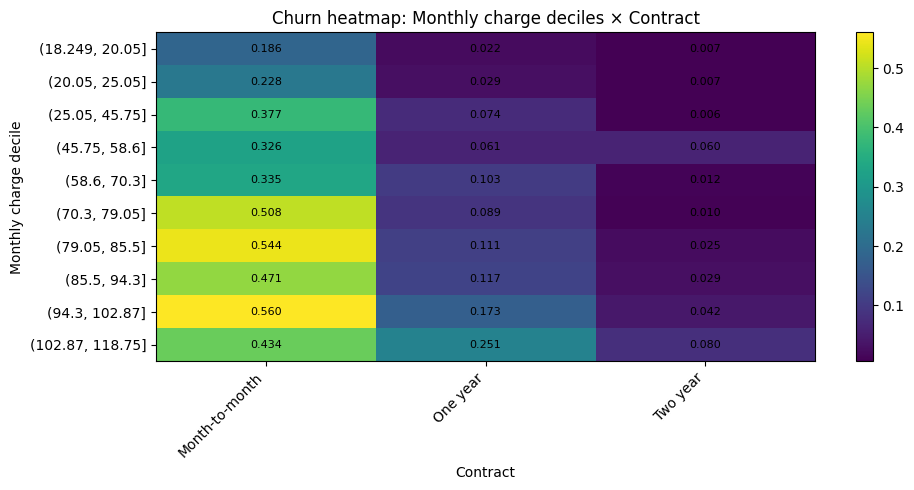

In [ ]:
#Análisis (Mapa de Calor) entre los cobros mensuales 'account.Charges.Monthly'
#y el tipo de contrato.

df2["monthly_bin"] = pd.qcut(df2["account.Charges.Monthly"], q=10, duplicates="drop")

if "contract" not in df2.columns:
    contract_cols = [c for c in df2.columns if c.startswith("account.Contract_")]
    df2["contract"] = df2[contract_cols].idxmax(axis=1).str.replace("account.Contract_", "", regex=False)

pivot_mc = pd.pivot_table(
    df2,
    values="Churn",
    index="monthly_bin",
    columns="contract",
    aggfunc="mean",
    observed=False
)

fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(pivot_mc.values, aspect="auto")

ax.set_title("Churn heatmap: Monthly charge deciles × Contract")
ax.set_xlabel("Contract")
ax.set_ylabel("Monthly charge decile")

ax.set_xticks(range(pivot_mc.shape[1]))
ax.set_xticklabels(pivot_mc.columns, rotation=45, ha="right")

ax.set_yticks(range(pivot_mc.shape[0]))
ax.set_yticklabels([str(x) for x in pivot_mc.index])

for i in range(pivot_mc.shape[0]):
    for j in range(pivot_mc.shape[1]):
        ax.text(j, i, f"{pivot_mc.values[i, j]:.3f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


<a name="contrato-vs-metodo-de-pago-vs-internet"></a>
###Análisis de Churn entre el tipo de contrato VS el método de pago VS servicio de Internet

In [ ]:
import pandas as pd

# Ensure the helper "contract" label exists (as we did before)
if "contract" not in df2.columns:
    contract_cols = [c for c in df2.columns if c.startswith("account.Contract_")]
    df2["contract"] = df2[contract_cols].idxmax(axis=1).str.replace("account.Contract_", "", regex=False)

internet_cols = [c for c in df2.columns if c.startswith("internet.InternetService_")]
df2["internet"] = df2[internet_cols].idxmax(axis=1).str.replace("internet.InternetService_", "", regex=False)

seg = (df2
       .groupby(["contract", "account.PaymentMethod", "internet"])
       .agg(churn_rate=("Churn","mean"), customers=("Churn","size"))
       .reset_index()
       .sort_values(["churn_rate","customers"], ascending=[False, False]))

baseline = df2["Churn"].mean()

seg["lift"] = seg["churn_rate"] / baseline
seg.sort_values(["lift","customers"], ascending=[False, False]).head(15)


,contract,account.PaymentMethod,internet,churn_rate,customers,lift
7,Month-to-month,Electronic check,Fiber optic,0.581430,1357,2.260700
10,Month-to-month,Mailed check,Fiber optic,0.490385,208,1.906701
1,Month-to-month,Bank transfer (automatic),Fiber optic,0.443452,336,1.724221
4,Month-to-month,Credit card (automatic),Fiber optic,0.409396,298,1.591803
6,Month-to-month,Electronic check,DSL,0.393443,488,1.529774
9,Month-to-month,Mailed check,DSL,0.299735,377,1.165421
3,Month-to-month,Credit card (automatic),DSL,0.257732,194,1.002107
19,One year,Electronic check,Fiber optic,0.250000,204,0.972044
11,Month-to-month,Mailed check,No internet service,0.197059,340,0.766199
0,Month-to-month,Bank transfer (automatic),DSL,0.193069,202,0.750687


##Ver tarjeta "¡Extra! Análisis de correlación entre variables" de Trello

##Correlación y revisiones de redundancia (evitar señales de sobreconteo) (Correlation and redundancy checks (avoid overcounting signals))

<a name="correlacion-churn"></a>
###Análisis de correlación entre Churn y las variables

In [ ]:
corr = df.drop(columns=['customerID']).corr(numeric_only=True)
corr['Churn'].sort_values(ascending=False).head(40)

,Churn
Churn,1.000000
account.Contract_Month-to-month,0.395584
internet.OnlineSecurity_No,0.335656
internet.TechSupport_No,0.330446
internet.InternetService_Fiber optic,0.300949
internet.OnlineBackup_No,0.263111
internet.DeviceProtection_No,0.246919
account.Charges.Daily,0.189866
account.Charges.Monthly,0.189866
account.PaperlessBilling,0.186666


<a name="correlacion-top-variables-vs-churn"></a>
###Análisis de correlación entre las variables top 20 variables contra 'Churn'

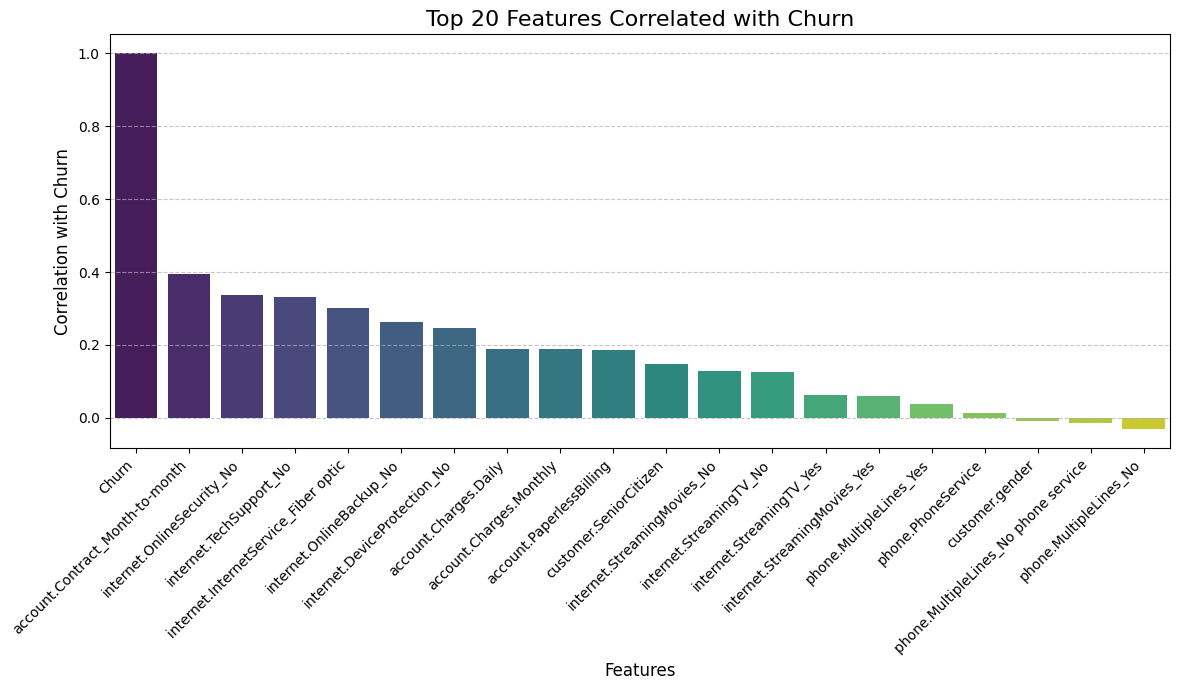

In [ ]:
#Gráfico de (X = 20) varibles correlacionadas VS 'Churn' excepto 'customerID'

import matplotlib.pyplot as plt
import seaborn as sns

corr = df.drop(columns=['customerID']).corr(numeric_only=True)
corr['Churn'].sort_values(ascending=False).head(40)

# Get the correlation series
churn_correlation = corr['Churn'].sort_values(ascending=False).head(20)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=churn_correlation.index, y=churn_correlation.values, palette='viridis', hue=churn_correlation.index, legend=False)
plt.title('Top 20 Features Correlated with Churn', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with Churn', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<a name="relacion-charges-daily-vs-churn"></a>
###Análisis de correlación entre 'account.Charges.Daily' y 'Churn'

In [ ]:
#Obtener la correlación de 'account.Charges.Daily' VS 'Churn'

#Remove missing values just in case
subset = df[['account.Charges.Daily', 'Churn']].dropna()

corr_value = subset['account.Charges.Daily'].corr(subset['Churn'])

print("Correlation between Daily Charges and Churn:", corr_value)

Correlation between Daily Charges and Churn: 0.1898657177458538


In [ ]:
#Statistical significance (Is it Real?)
#If p-value < 0.05, the correlation is statistically significant.
# p-value >= 0.05 -> random variation

from scipy.stats import pointbiserialr

r, p_value = pointbiserialr(
    subset['Churn'],
    subset['account.Charges.Daily']
)

print("Correlation:", r)
print("P-value:", p_value)

Correlation: 0.18986571774585384
P-value: 5.901031336770757e-60


<a name="servicios-vs-churn"></a>
###Análisis de cómo la cantidad de servicios contratados afecta la probabilidad de churn.

In [ ]:
#Define el número de servicios de acuerdo lo que se incluye en el combo

# 1) Internet service: count 1 if customer has internet (i.e., NOT "No internet service")
if "internet.InternetService_No internet service" in df2.columns:
    has_internet = 1 - df2["internet.InternetService_No internet service"]
else:
    # fallback: if you have a direct binary
    has_internet = df2.get("internet.InternetService", pd.Series(0, index=df2.index))

# 2) Phone service (if exists)
has_phone = df2.get("phone.PhoneService", pd.Series(0, index=df2.index))

# 3) Add-ons: count only the *_Yes columns (avoid *_No columns)
addon_yes_cols = [c for c in df2.columns
                  if c.startswith("internet.") and c.endswith("_Yes")]

# Streaming yes cols often exist too (depending on dataset naming)
stream_yes_cols = [c for c in df2.columns
                   if ("Streaming" in c or "streaming" in c) and c.endswith("_Yes")]

# Multiple lines yes (if one-hot)
ml_yes = df2.get("phone.MultipleLines_Yes", pd.Series(0, index=df2.index))

# 4) Total number of services
df2["num_services"] = (
    has_phone.astype(int)
    + has_internet.astype(int)
    + ml_yes.astype(int)
    + df2[addon_yes_cols].sum(axis=1).astype(int)
    + (df2[stream_yes_cols].sum(axis=1).astype(int) if len(stream_yes_cols) else 0)
)

df2["num_services"].describe()

,num_services
count,7267.000000
mean,4.912619
std,3.022157
min,1.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,11.000000


In [ ]:
#Cuenta los clientes y el Churn rate de acuerdo al numero de servicios existentes

churn_by_n = df2.groupby("num_services")["Churn"].mean()
counts_by_n = df2["num_services"].value_counts().sort_index()

summary = pd.DataFrame({
    "customers": counts_by_n,
    "churn_rate": churn_by_n
}).fillna(0)

summary

,customers,churn_rate
num_services,,
1,1306,0.105666
2,865,0.284393
3,649,0.402157
4,706,0.362606
5,650,0.329231
6,650,0.280000
7,679,0.285714
8,631,0.291601
9,582,0.237113


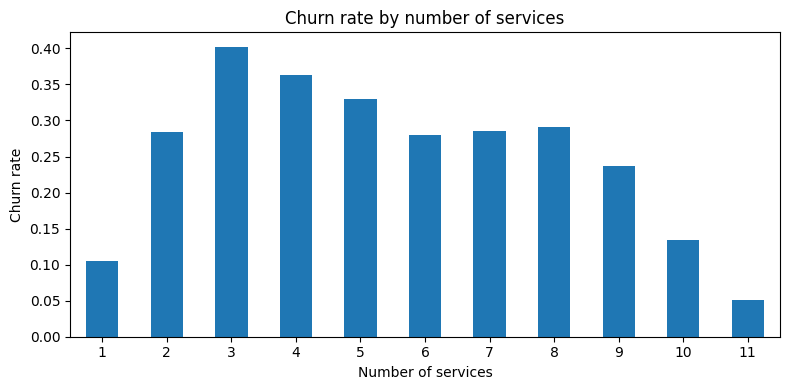

In [ ]:
#Grafica el numero de servicios existentes VS 'Churn'

import matplotlib.pyplot as plt

ax = summary["churn_rate"].plot(kind="bar", figsize=(8,4), rot=0)
ax.set_title("Churn rate by number of services")
ax.set_xlabel("Number of services")
ax.set_ylabel("Churn rate")
plt.tight_layout()
plt.show()

In [ ]:
corr = df2["num_services"].corr(df2["Churn"])
print("Correlation(num_services, Churn):", corr)

Correlation(num_services, Churn): 0.006283794708526526


In [ ]:
#Statistical significance (Is it Real?)
#If p-value < 0.05, the correlation is statistically significant.
# p-value >= 0.05 -> random variation

from scipy.stats import pointbiserialr

r, p = pointbiserialr(df2["Churn"], df2["num_services"])
print("r:", r)
print("p-value:", p)

r: 0.006283794708526518
p-value: 0.5922447715069052


<a name="top-variables-abandono-retencion"></a>
###Análisis de las top variables para evitar el abandono y las top variables para aumentar la retención

In [ ]:
#Obtención de variables que hay que revisar para evitar el abandono ('Churn')
# (Variables con valores 'Churn' altos)
#Obtención de variables que hay que revisar para evitar el abandono ('Churn')
# (Variables con valores 'Churn' bajos)

exclude = {"customerID", "Churn", "account.PaymentMethod"}
binary_cols = [c for c in df.columns if c not in exclude and set(df[c].unique()) <= {0, 1}]

compare = (df.groupby("Churn")[binary_cols].mean().T
             .rename(columns={0: "non_churn_rate", 1: "churn_rate"}))
compare["diff"] = compare["churn_rate"] - compare["non_churn_rate"]

top_risk = compare.sort_values("diff", ascending=False).head(10)
top_protective = compare.sort_values("diff", ascending=True).head(10)

print(f"Churneros Rehabilitadores\n{top_risk}\n")
print(f"No Churneros Rehabilitadores\n{top_protective}")


Churneros Rehabilitadores
Churn                                 non_churn_rate  churn_rate      diff
account.Contract_Month-to-month             0.435346    0.885500  0.450154
internet.OnlineSecurity_No                  0.397740    0.781701  0.383962
internet.TechSupport_No                     0.395702    0.773676  0.377974
internet.InternetService_Fiber optic        0.352167    0.693954  0.341787
internet.OnlineBackup_No                    0.361060    0.659711  0.298651
internet.DeviceProtection_No                0.367544    0.647940  0.280397
account.PaperlessBilling                    0.539274    0.749064  0.209790
internet.StreamingMovies_No                 0.357910    0.501873  0.143962
internet.StreamingTV_No                     0.361986    0.504013  0.142027
customer.SeniorCitizen                      0.130789    0.254682  0.123892

No Churneros Rehabilitadores
Churn                                          non_churn_rate  churn_rate  \
account.Contract_Two year                 

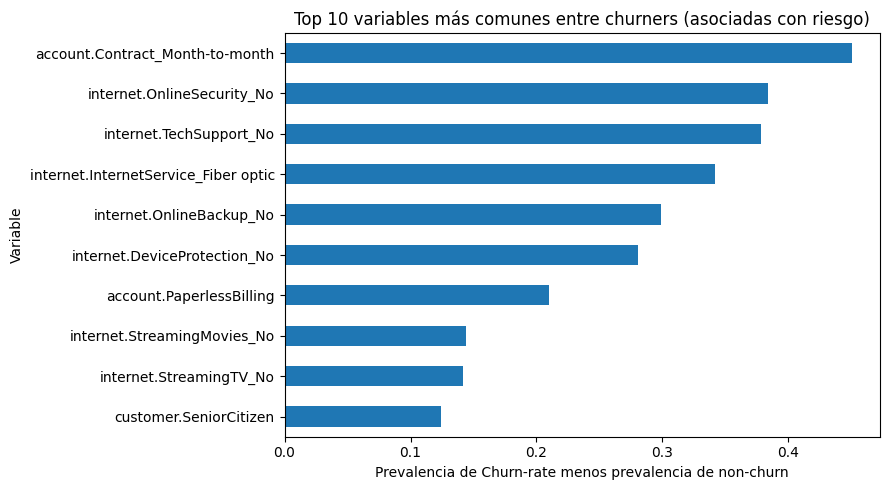

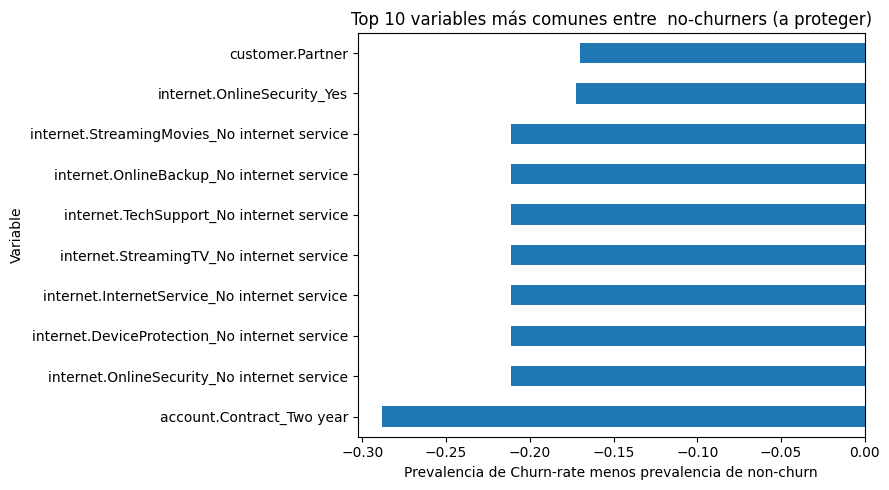

In [ ]:
#Obtención de variables que hay que revisar para evitar el abandono ('Churn')
# (Variables con valores 'Churn' altos)
#Obtención de variables que hay que revisar para evitar el abandono ('Churn')
# (Variables con valores 'Churn' bajos)
#Gráfico

if "contract" not in df2.columns:
    contract_cols = [c for c in df2.columns if c.startswith("account.Contract_")]
    df2["contract"] = df2[contract_cols].idxmax(axis=1).str.replace("account.Contract_", "", regex=False)

# Create readable internet service label if it doesn't exist
if "internet" not in df2.columns:
    internet_cols = [c for c in df2.columns if c.startswith("internet.InternetService_")]
    df2["internet"] = df2[internet_cols].idxmax(axis=1).str.replace("internet.InternetService_", "", regex=False)

exclude = {"customerID", "Churn", "account.PaymentMethod", "contract", "internet"}
binary_cols = [c for c in df2.columns if c not in exclude and set(df2[c].unique()) <= {0, 1}]

compare = (df2.groupby("Churn")[binary_cols].mean().T
             .rename(columns={0: "non_churn_rate", 1: "churn_rate"}))
compare["diff"] = compare["churn_rate"] - compare["non_churn_rate"]

top_risk = compare.sort_values("diff", ascending=False).head(10)
top_prot = compare.sort_values("diff", ascending=True).head(10)

# Plot both side-by-side (two separate figures keeps it clean)
ax = top_risk["diff"].sort_values().plot(kind="barh", figsize=(9,5))
ax.set_title("Top 10 variables más comunes entre churners (asociadas con riesgo)")
ax.set_xlabel("Prevalencia de Churn-rate menos prevalencia de non-churn")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

ax = top_prot["diff"].sort_values().plot(kind="barh", figsize=(9,5))
ax.set_title("Top 10 variables más comunes entre  no-churners (a proteger)")
ax.set_xlabel("Prevalencia de Churn-rate menos prevalencia de non-churn")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


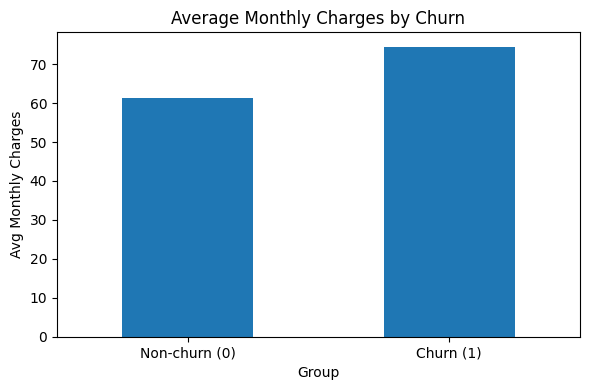

In [ ]:
#Análisis de 'Churn' VS 'account.Charges.Monthly'

charges_by_churn = df.groupby("Churn")["account.Charges.Monthly"].mean()
charges_by_churn.index = ["Non-churn (0)", "Churn (1)"]

ax = charges_by_churn.plot(kind="bar", rot=0, figsize=(6,4))
ax.set_title("Average Monthly Charges by Churn")
ax.set_xlabel("Group")
ax.set_ylabel("Avg Monthly Charges")
plt.tight_layout()
plt.show()


#📄Informe final

###**Introducción**.
###
###**TelecomX** es una compañía de servicios de telecomunicación que ofrece diversos servicios a clientes tanto de telefonía, Internet, Soporte Técnico, así como de entretenimiento. Se nos ha buscado como analistas de datos para hacer un análisis del estado actual del servicio en general.
###El objetivo del análisis es apoyar a la empresa **TelecomX** a minimizar a través de un análisis de datos la evasión de clientes (Churn) en la compañía debido a factores que ignora de momento y al mismo tiempo fortalecer el servicio a través del descubrimiento que ofrece la Ciencia de Datos sobre los hallazgos que influyan en la percepción del cliente de los servicios que ofrece **TelecomX** con el objetivo final de la mejora contínua.
<!--
LLM Prompt
A manera de adelantar el trabajo, hasta este momento, hemos analizado y limpiado los datos de acuerdo a las buenas prácticas de Ciencia de Datos, sin embargo tu eres un experto en Ciencia de Datos y puedes opcionalmente revisar el avance.

Se te provee el archivo donde esto se refleja y ahora quiero revisar contigo el análisis de los posibles hallazgos que se pueden encontrar para concluir con éxito el objetivo y apoyar a TelecomX a disminuir o atacar el 'Churn'.

El tema hasta hora deberá ser solo de búsqueda de insights o hallazgos sin utilizar Machine Learning.

Te pido que revises el archivo inicial y que no inicies ningún análisis hasta que yo te lo pida.
-->

###**Limpieza y Tratamiento de Datos.** ###
###En esta sección se describen los pasos realizados para importar, limpiar y procesar los datos. Primeramente se hizo una carga y exploración inicial de los datos para ver su estructura y conocer sus estadísticos iniciales.
###
###La carga se llevo a cabo a través de un archivo JSON y se hizo en la parte [extracción](#extraccion) de este documento. Posteriormente se hizo un descubrimiento de datos para conocer sus estadísticos y así [conocer el conjunto de datos](#conoce-el-conjunto-de-datos). Para comprender la semántica del conjunto de datos, hubo que revisar los [metadatos que fueron provistos](https://github.com/ingridcristh/challenge2-data-science-LATAM) para entender cada una de las variables o columnas de información de la tabla inicial de clientes de la Base de Datos.
###
###Una vez conocido el conjunto inicial de datos, se procede a la [transformación](#transformacion) consistente en los siguientes pasos:

1.   [Verificar la integridad de la columna](#validacion-de-la-integridad-de-la-variable-customerid) **'CustomerID'**. La columna 'CustomerID' debe tener un formato dddd-LLLL (4 dígitos [0-9] + "-" + 5 letras mayúsculas del conjunto [A-Z].
2.   [Verificar la unicidad de la columna](#verificacion-de-la-unicidad-de-la-variable-customerid) **'CustomerID'**. La columna 'CustomerID' debe ser única ya que funciona como llave única de cada cliente.
3.   Se crea la función [summarize_unique_values](#summarize-unique-values) la cual hace un análisis de todos los valores únicos de una variable o columna, al final da un resúmen del conteo, la frecuencia de cada valor y el valor del dato de la variable. EL objetivo es conocer los valores y proceder a normalizarlos con valores de 0 y 1 en caso de ser binarios, y/o a utilizar One-Hot-Encoding a través de la función [convert_column_to_OHE](#convert-column-to-OHE) si el número de valores únicos es igual a 3 (por convención) para normalizar en términos de 0 y 1. En general, la política de número de valores únicos en una variable se rije por la siguiente trasformación:

     *   Variable binaria: Valores 0 y 1
     *   Variable ternaria: Variable convertida a OHE. Valores 0 y 1
     *   Variable n-aria (n > 3): Valores quedan igual


4.   Una vez conocidos los valores de una variable se pueden tomar decisiones sobre su posible plan de normalización; pero antes se revisa que las inconsistencias (valores nulos, **NaN**, espacios, etc) sean corregidas a través de alguna política. La función [recode_to_binary](#recode-to-binary) se encarga de hacer esa normalización de acuerdo a las siguientes políticas de valores:

     *   "Male, True, "1", "Yes" = 1
     *   "Female, False, "0", "No" = 0

   
5.   Para este caso en particular, al revisar que el número de inconsistencias no es tan alto, se decide solo transformarlas con un valor default (0 en el caso de la columna **'Churn'**) y con la mediana en el caso de la columna **'account.Charges.Total'**. Para este caso hace la validación y posterior conversión con la función [convert_column_to_float_strict](#convert-column-to-float-strict)
6.    Se crea la columna [Account.Charges.Daily](#create-column-account-charges-daily) a partir de la columna 'Account.Charges.Montly'.


###**Análisis Exploratorio de Datos.**
###En esta sección se presentan los análisis realizados, incluyendo gráficos y visualizaciones para identificar patrones.
###Primeramente se identifica a nivel global [el 'Churn' en la población](#analisis-de-churn-base). Esa es nuestra base para partir al análisis.
###Segundo, la sábana de datos muestra distintas varibles categóricas y numéricas que podrían influir en los valores mostrados de 'Churn'. Para descubrir los valores y sus relaciones, hacemos uso de las funciones [churn_by_category](#churn-by-category), [churn_rate_by](#churn-rate-by), [churn_by_numeric_bins](#churn-by-numeric-bins) (esta función divide en bins o grupos poblacionales con el objetivo de comparar elementos similares a manera de perceptiles). Por último el bloque [churn_by_numeric](#churn_by_numeric) hace un análisis similar pero sin utilizar bins.
###Como parte del análisis de variables categóricas, se escogen aquellas que han mostrado un 'Churn' destacado. Hacemos uso de las funciones [análisis de la variable categórica 'PaymentMethod' contra 'Churn'](#churn-by-pay), [Análisis de la variable categórica 'account.Contract' contra 'Churn'](#churn-by-accout-contract), y [análisis de la variable categórica 'internet.InternetService' contra 'Churn'](#churn-by-accout-internet) para comprobar el 'Churn' contra estas categorías.
###Tercero, se obtiene un resumen general del peso del 'Churn' y el análisis del peso de cada variable junto con este 'Churn', obteniendo características como conteo de clientes, análisis de 'Churn', probabilidad de X dado el 'Churn' (para saber la presencia de X en casos de 'Churn'), etc. Esto se hace en la función [binary_driver_summary](#binary-driver-summary) y el bloque [sumario de variables binarias de servicio contra 'Churn'](#service-churn).
###Cuarto, como parte de los hallazgos en la exploración anterior, en esta parte se combinan variables para ver los efectos de interacción respecto al 'Churn'. Aquí se muestran ejemplos como [análisis de Churn entre el tipo de contrato VS el método de pago](#contrato-vs-metodo-de-pago),  [análisis de Churn entre el tipo de contrato VS el servicio de Internet](#contrato-vs-servicio-de-internet),  [análisis entre los cobros mensuales 'account.Charges.Monthly' y el tipo de contrato](#cobro-mensual-vs-servicio-de-internet) y el [análisis de Churn entre el tipo de contrato VS el método de pago VS servicio de Internet](#contrato-vs-metodo-de-pago-vs-internet), aunque se pueden desarrollar cualquier combinación para ver interacciones entre variables y posibles insigths.
###Quinto, se hace un análisis muy básico de [correlaciones entre 'Churn' y las variables](#correlacion-churn) y tambien esto comprueba hallazgos anteriores lo cual queda evidenciado en el chart [análisis de correlación entre las top 20 variables contra 'Churn'](#correlacion-top-variables-vs-churn) Se contestan preguntas como [la relación entre la cuenta diaria y la evasión](#relacion-charges-daily-vs-churn) y la pregunta sobre [cómo la cantidad de servicios contratados afecta la probabilidad de churn](#servicios-vs-churn).
###Sexto, se presenta un valioso informe que analiza las variables que habrá que tomar en cuenta para evitar el abandono y tambien aquellas variables para fortalecer la permanencia. El informe se presenta bajo [análisis de las top variables para evitar el abandono y las top variables para aumentar la retención](#top-variables-abandono-retencion)
###
###
###
###
###
###
###
###
###


###**Conclusiones e Insights**.
###
###En esta sección se resumen los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.
###**Hallazgos:**
###**Foto general**

* Churn global: 25.72% (≈ 1 de cada 4 clientes se va).


In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/images/Churn_general_tasa_base.png"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/images/Churn_general_tasa_base.png'

###A) El contrato es el mayor diferenciador de 'Churn'.

*   Month-to-month: 41.32%
*   1 año: 10.93%
*   2 años: 2.75%
*   Riesgo relativo: el churn en month-to-month es **~6.3×** el churn de clientes no month-to-month.
###**Interpretación:** el churn no está “uniformemente repartido”; está concentrado en clientes sin amarre de permanencia.

###**Acción directa:** campañas y ofertas para migrar month-to-month a 1 año / 2 años (con algún tipo de incentivos, oferta o bundle).




In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/images/Churn_rate_por_tipo_de_contrato.png"))


###B) Tipo de Internet: fibra óptica concentra 'Churn' alto

* Fiber optic: 40.56%

* DSL: 18.45%

* Sin internet: 7.15%

###**Interpretación:** “fibra” es un cluster de riesgo. Puede ser mezcla de: precio más alto, expectativas más altas, calidad percibida, incidencias, instalación, competencia, etc.

###**Acción directa:** abrir una línea de trabajo específica para clientes de fibra, especialmente los nuevos y los que no tienen servicios “de protección” (soporte/seguridad).



In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/images/Churn_rate_por_tipo_de_internet.png"))


###C) Método de pago: “Electronic check” es señal de alerta

* Electronic check: 43.80%

* Mailed check: 18.50%

* Bank transfer (auto): 16.24%

* Credit card (auto): 14.80%

###**Interpretación:** hay un problema de fricción / perfil asociado a electronic check (y típicamente se combina con month-to-month).

###**Acción directa:** migración agresiva a autopago (tarjeta/transferencia automática) con incentivos + comunicación clara. Esta migración podría suponer *n* meses de un servicio adicional a quien cambie su método de pago.



In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/images/Churn_rate_por_metodo_de_pago.png"))


###D) Soporte técnico y seguridad online son “palancas protectoras” muy claras

###En clientes con Internet:

###TechSupport = No: 40.37% vs Yes: 14.73% (≈ 2.74×)

###OnlineSecurity = No: 40.49% vs Yes: 14.20% (≈ 2.85×)

###**Interpretación:** más que “add-ons”, parecen ser mecanismos de retención (o proxies de satisfacción/acompañamiento).

###**Acción directa:** bundles/upsell muy focalizado: Soporte + Seguridad como “paquete anti-churn” (especialmente en fibra y month-to-month). El bundle podría incluso contener OnLine Backup y DeviceProtection para atacar dos variables más en el top de variables de servicios de Internet con churners. En este [sumario de variables binarias contra 'Churn'](#binary-driver-summary) se observan los valores.





In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/images/Add_ons_vs_Churn_solo_internet.png"))

###E) Timing del churn: el “peligro” está al inicio (tenure)

Churn por antigüedad (meses):

* 0–3: 54.37%

* 3–9: 39.32%

* 9–17: 33.41%

…

* 67–72: 4.6%

###**Interpretación:** la fuga está hiper-concentrada en onboarding y primeros ciclos de facturación/uso.

###**Acción directa:** programa de retención temprana:

* llamadas/check-in post instalación,

* monitoreo de primeras incidencias,

* “primer recibo explicado”,

* ofertas de upgrade de contrato antes del mes 3.

###En este [análisis de variables numéricas contra 'Churn' usando grupos para dividir percentiles en la permanencia](#churn_by_numeric_bins) se demuestra esta situación.
###
###
###
###

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/images/Churn_rate_por_antiguedad_tenure_bins.png"))

###**Recomendaciones**.

###Como una sugerencia estratégica se recomienda armar bundles de permanencia a largo plazo, con add-ons que incluyan seguridad, respaldo, soporte técnico y al mismo tiempo internamente preparar los grupos de soporte para dar servicio premium a los clientes nuevos o con poco tiempo para demostrar una competitividad alta en **TelecomX**.
###Estos bundles deben incluir servicios de entretenimiento temporales, descuentos al pagar por adelantado servicios por medios electrónicos como transferencias (SPEI) y tarjetas de crédito.
###Se observa claramente que la empresa tiene ademas una taas sustancial de abandono en donde se tienen servicios que incluyen internet y en donde el cliente desconfia de los servicios o no los incluye. Siguiente paso, una fuerte campaña de atracción a estos servicios en conjunto con las estratégias señaladas.